# The Fare Amount Prediction Of Future Rides Using Regression Analysis

In [2]:
# importing libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time, datetime
from sklearn.preprocessing import MinMaxScaler
from math import sin, cos, sqrt, radians, atan2 
from sklearn.model_selection import train_test_split

import warnings as wrn
wrn.filterwarnings ('ignore')

In [3]:
# to load the data

uber_data = pd.read_csv("F:\\Mentormind\\uber.csv")
uber_data.head()

,Unnamed: 0,key,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
0,24238194,2015-05-07 19:52:06.0000003,7.5,2015-05-07 19:52:06 UTC,-73.999817,40.738354,-73.999512,40.723217,1
1,27835199,2009-07-17 20:04:56.0000002,7.7,2009-07-17 20:04:56 UTC,-73.994355,40.728225,-73.994710,40.750325,1
2,44984355,2009-08-24 21:45:00.00000061,12.9,2009-08-24 21:45:00 UTC,-74.005043,40.740770,-73.962565,40.772647,1
3,25894730,2009-06-26 08:22:21.0000001,5.3,2009-06-26 08:22:21 UTC,-73.976124,40.790844,-73.965316,40.803349,3
4,17610152,2014-08-28 17:47:00.000000188,16.0,2014-08-28 17:47:00 UTC,-73.925023,40.744085,-73.973082,40.761247,5


In [4]:
# total cells in the table

uber_data.size

1800000

In [5]:
# total rows & columns

uber_data.shape

(200000, 9)

In [6]:
# to find the data-type & Non-Null values

uber_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 9 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Unnamed: 0         200000 non-null  int64  
 1   key                200000 non-null  object 
 2   fare_amount        200000 non-null  float64
 3   pickup_datetime    200000 non-null  object 
 4   pickup_longitude   200000 non-null  float64
 5   pickup_latitude    200000 non-null  float64
 6   dropoff_longitude  199999 non-null  float64
 7   dropoff_latitude   199999 non-null  float64
 8   passenger_count    200000 non-null  int64  
dtypes: float64(5), int64(2), object(2)
memory usage: 13.7+ MB


In [7]:
# to find the total null values 

uber_data.isna().sum()

Unnamed: 0           0
key                  0
fare_amount          0
pickup_datetime      0
pickup_longitude     0
pickup_latitude      0
dropoff_longitude    1
dropoff_latitude     1
passenger_count      0
dtype: int64

In [8]:
# to find the list of all the columns in the dataset

uber_data.columns

Index(['Unnamed: 0', 'key', 'fare_amount', 'pickup_datetime',
       'pickup_longitude', 'pickup_latitude', 'dropoff_longitude',
       'dropoff_latitude', 'passenger_count'],
      dtype='object')

In [9]:
# to find the index of row having null value
uber_data.loc[uber_data['dropoff_longitude'].isnull(), ]

,Unnamed: 0,key,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
87946,32736015,2013-07-02 03:51:57.0000001,24.1,2013-07-02 03:51:57 UTC,-73.950581,40.779692,NaN,NaN,0


In [10]:
# to extract the 'fare_amount' column from the table
col = uber_data.pop('fare_amount')

In [11]:
# to re-arrange the target column in the end
uber_data.insert(8, 'fare_amount', col)

In [12]:
uber_data.head(5)

,Unnamed: 0,key,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,fare_amount
0,24238194,2015-05-07 19:52:06.0000003,2015-05-07 19:52:06 UTC,-73.999817,40.738354,-73.999512,40.723217,1,7.5
1,27835199,2009-07-17 20:04:56.0000002,2009-07-17 20:04:56 UTC,-73.994355,40.728225,-73.994710,40.750325,1,7.7
2,44984355,2009-08-24 21:45:00.00000061,2009-08-24 21:45:00 UTC,-74.005043,40.740770,-73.962565,40.772647,1,12.9
3,25894730,2009-06-26 08:22:21.0000001,2009-06-26 08:22:21 UTC,-73.976124,40.790844,-73.965316,40.803349,3,5.3
4,17610152,2014-08-28 17:47:00.000000188,2014-08-28 17:47:00 UTC,-73.925023,40.744085,-73.973082,40.761247,5,16.0


## Missing-value

In [13]:
# as we have only 2 missing value in the same row , and the missing values are the coordinates of the location , so instead of fill these we will drop that onw row.....
uber_data.drop(87946, axis = 0, inplace = True)

In [14]:
# new shape after removing one row
uber_data.shape

(199999, 9)

In [15]:
uber_data.head()

,Unnamed: 0,key,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,fare_amount
0,24238194,2015-05-07 19:52:06.0000003,2015-05-07 19:52:06 UTC,-73.999817,40.738354,-73.999512,40.723217,1,7.5
1,27835199,2009-07-17 20:04:56.0000002,2009-07-17 20:04:56 UTC,-73.994355,40.728225,-73.994710,40.750325,1,7.7
2,44984355,2009-08-24 21:45:00.00000061,2009-08-24 21:45:00 UTC,-74.005043,40.740770,-73.962565,40.772647,1,12.9
3,25894730,2009-06-26 08:22:21.0000001,2009-06-26 08:22:21 UTC,-73.976124,40.790844,-73.965316,40.803349,3,5.3
4,17610152,2014-08-28 17:47:00.000000188,2014-08-28 17:47:00 UTC,-73.925023,40.744085,-73.973082,40.761247,5,16.0


## Feature-engineering 

In [16]:
uber_data.shape

(199999, 9)

In [17]:
# as column 'pickup_datetime' data-type is object , so further using it, we will have to change the data-type into datetime..
uber_data['pickup_datetime'] = pd.to_datetime(uber_data['pickup_datetime'])

In [18]:
# to extract 'year' from the date..
uber_data.insert(3, 'pickup_year', uber_data['pickup_datetime'].dt.year)

In [19]:
# to extract 'month' from the date...
uber_data.insert(4, 'pickup_month', uber_data['pickup_datetime'].dt.month)

In [20]:
# to extract 'date' from the date...
uber_data.insert(5, 'pickup_date', uber_data['pickup_datetime'].dt.day)

In [21]:
# to extract exact 'hour' from the time...
uber_data.insert(6, 'pickup_hour', uber_data['pickup_datetime'].dt.hour)

In [22]:
# to extract 'day' from the date....
uber_data.insert(7, 'pickup_day', uber_data['pickup_datetime'].dt.dayofweek)

In [23]:
# to create the column if the day is weekend or a weekday...
uber_data.insert(8, 'is_weekend', uber_data['pickup_day'].apply(lambda x : 1 if x>=5 else 0))

In [24]:
uber_data.head(5)

,Unnamed: 0,key,pickup_datetime,pickup_year,pickup_month,pickup_date,pickup_hour,pickup_day,is_weekend,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,fare_amount
0,24238194,2015-05-07 19:52:06.0000003,2015-05-07 19:52:06+00:00,2015,5,7,19,3,0,-73.999817,40.738354,-73.999512,40.723217,1,7.5
1,27835199,2009-07-17 20:04:56.0000002,2009-07-17 20:04:56+00:00,2009,7,17,20,4,0,-73.994355,40.728225,-73.994710,40.750325,1,7.7
2,44984355,2009-08-24 21:45:00.00000061,2009-08-24 21:45:00+00:00,2009,8,24,21,0,0,-74.005043,40.740770,-73.962565,40.772647,1,12.9
3,25894730,2009-06-26 08:22:21.0000001,2009-06-26 08:22:21+00:00,2009,6,26,8,4,0,-73.976124,40.790844,-73.965316,40.803349,3,5.3
4,17610152,2014-08-28 17:47:00.000000188,2014-08-28 17:47:00+00:00,2014,8,28,17,3,0,-73.925023,40.744085,-73.973082,40.761247,5,16.0


In [25]:
uber_data.shape

(199999, 15)

In [26]:
# now as we have extracted all date and time columns, we can drop these columns...
uber_data.drop(['pickup_datetime', 'Unnamed: 0', 'key', 'pickup_day'], axis = 1, inplace = True)

In [27]:
# new shape
uber_data.shape

(199999, 11)

In [28]:
uber_data.head()

,pickup_year,pickup_month,pickup_date,pickup_hour,is_weekend,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,fare_amount
0,2015,5,7,19,0,-73.999817,40.738354,-73.999512,40.723217,1,7.5
1,2009,7,17,20,0,-73.994355,40.728225,-73.994710,40.750325,1,7.7
2,2009,8,24,21,0,-74.005043,40.740770,-73.962565,40.772647,1,12.9
3,2009,6,26,8,0,-73.976124,40.790844,-73.965316,40.803349,3,5.3
4,2014,8,28,17,0,-73.925023,40.744085,-73.973082,40.761247,5,16.0


### -- to extract "Distance" from these co-ordinates (given for the location) 

In [29]:
data = uber_data[['pickup_longitude', 'pickup_latitude', 'dropoff_longitude','dropoff_latitude',]]

In [30]:
data

,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude
0,-73.999817,40.738354,-73.999512,40.723217
1,-73.994355,40.728225,-73.994710,40.750325
2,-74.005043,40.740770,-73.962565,40.772647
3,-73.976124,40.790844,-73.965316,40.803349
4,-73.925023,40.744085,-73.973082,40.761247
...,...,...,...,...
199995,-73.987042,40.739367,-73.986525,40.740297
199996,-73.984722,40.736837,-74.006672,40.739620
199997,-73.986017,40.756487,-73.858957,40.692588
199998,-73.997124,40.725452,-73.983215,40.695415


In [31]:
# to create a function for extracting distance (in km) from co-ordinates..
def distance(data):
    R = 6373.0
    data['pickup_longitude'] = data['pickup_longitude'].apply(radians)
    data['pickup_latitude'] = data['pickup_latitude'].apply(radians)
    data['dropoff_longitude'] = data['dropoff_longitude'].apply(radians)
    data['dropoff_latitude'] = data['dropoff_latitude'].apply(radians)

    data['long_diff'] = data['dropoff_longitude'] - data['pickup_longitude']
    data['lat_diff'] = data['dropoff_latitude'] - data['pickup_latitude']
    
    data['intermediaire'] = (data['lat_diff']/2).apply(sin)**2 + data['pickup_latitude'].apply(cos) * data['dropoff_latitude'].apply(cos) *  (data['long_diff']/2).apply(sin)**2

    data['distance'] = R*np.atan2((data['intermediaire']).apply(sqrt), (1- data['intermediaire']).apply(sqrt))

    return data

In [32]:
# created the distance column
distance(data)

,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,long_diff,lat_diff,intermediaire,distance
0,-1.291540,0.711018,-1.291535,0.710754,0.000005,-0.000264,1.745258e-08,0.841926
1,-1.291445,0.710842,-1.291451,0.711227,-0.000006,0.000386,3.720006e-08,1.229181
2,-1.291632,0.711061,-1.290890,0.711617,0.000741,0.000556,1.562289e-07,2.518979
3,-1.291127,0.711935,-1.290938,0.712153,0.000189,0.000218,1.700675e-08,0.831103
4,-1.290235,0.711118,-1.291074,0.711418,-0.000839,0.000300,1.233668e-07,2.238427
...,...,...,...,...,...,...,...,...
199995,-1.291317,0.711036,-1.291308,0.711052,0.000009,0.000016,7.755143e-11,0.056123
199996,-1.291277,0.710992,-1.291660,0.711041,-0.000383,0.000049,2.165462e-08,0.937819
199997,-1.291300,0.711335,-1.289082,0.710220,0.002218,-0.001115,1.017074e-06,6.427177
199998,-1.291493,0.710793,-1.291251,0.710269,0.000243,-0.000524,7.717231e-08,1.770413


In [33]:
col = data['distance']

In [34]:
# added the distance column in the table
uber_data.insert(5, 'distance', col)

In [35]:
# dropped all co-ordinates after retriving the distance from them
uber_data.drop(['pickup_longitude', 'pickup_latitude', 'dropoff_longitude','dropoff_latitude'], axis = 1, inplace = True)

In [36]:
uber_data.head()

,pickup_year,pickup_month,pickup_date,pickup_hour,is_weekend,distance,passenger_count,fare_amount
0,2015,5,7,19,0,0.841926,1,7.5
1,2009,7,17,20,0,1.229181,1,7.7
2,2009,8,24,21,0,2.518979,1,12.9
3,2009,6,26,8,0,0.831103,3,5.3
4,2014,8,28,17,0,2.238427,5,16.0


## Split The Dataset

In [37]:
uber_data.columns

Index(['pickup_year', 'pickup_month', 'pickup_date', 'pickup_hour',
       'is_weekend', 'distance', 'passenger_count', 'fare_amount'],
      dtype='object')

In [38]:
# to segregate all independent & target variables in to X, y...
X = uber_data[['pickup_year', 'pickup_month', 'pickup_date', 'pickup_hour',
       'is_weekend', 'distance' , 'passenger_count']]
y = uber_data['fare_amount']

In [39]:
X.head()

,pickup_year,pickup_month,pickup_date,pickup_hour,is_weekend,distance,passenger_count
0,2015,5,7,19,0,0.841926,1
1,2009,7,17,20,0,1.229181,1
2,2009,8,24,21,0,2.518979,1
3,2009,6,26,8,0,0.831103,3
4,2014,8,28,17,0,2.238427,5


In [40]:
# to spilt the whole data into train & test data
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size = 0.7, test_size = 0.3, random_state = 25)

In [41]:
# to find the number of rows and columns to train the data
X_train.shape

(139999, 7)

In [42]:
# to find the number of rows and columns to test the data
X_test.shape

(60000, 7)

In [43]:
y_train.shape

(139999,)

In [44]:
y_test.shape

(60000,)

## Data Scaling/Normalization

In [45]:
print(X_train.shape, X_test.shape)

(139999, 7) (60000, 7)


In [46]:
# created an object to bring all independent features on the same scale 
scaler = MinMaxScaler()

In [47]:
# fit the scaler to the train set, it will learn the pattern
scaler.fit(X_train)

# transform train and test both
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [48]:
# changed the data from numpy array format to dataframes ....
X_train_scaled = pd.DataFrame(X_train_scaled, columns = X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns = X_test.columns)

In [49]:
# Generate descriptive statistics
np.round(X_train.describe(), 1)

,pickup_year,pickup_month,pickup_date,pickup_hour,is_weekend,distance,passenger_count
count,139999.0,139999.0,139999.0,139999.0,139999.0,139999.0,139999.0
mean,2011.7,6.3,15.7,13.5,0.3,10.2,1.7
std,1.9,3.4,8.7,6.5,0.5,188.6,1.4
min,2009.0,1.0,1.0,0.0,0.0,0.0,0.0
25%,2010.0,3.0,8.0,9.0,0.0,0.6,1.0
50%,2012.0,6.0,16.0,14.0,0.0,1.1,1.0
75%,2013.0,9.0,23.0,19.0,1.0,1.9,2.0
max,2015.0,12.0,31.0,23.0,1.0,8207.2,208.0


In [50]:
# Generate descriptive statistics for scaled columns
np.round(X_train_scaled.describe(), 1)

,pickup_year,pickup_month,pickup_date,pickup_hour,is_weekend,distance,passenger_count
count,139999.0,139999.0,139999.0,139999.0,139999.0,139999.0,139999.0
mean,0.5,0.5,0.5,0.6,0.3,0.0,0.0
std,0.3,0.3,0.3,0.3,0.5,0.0,0.0
min,0.0,0.0,0.0,0.0,0.0,0.0,0.0
25%,0.2,0.2,0.2,0.4,0.0,0.0,0.0
50%,0.5,0.5,0.5,0.6,0.0,0.0,0.0
75%,0.7,0.7,0.7,0.8,1.0,0.0,0.0
max,1.0,1.0,1.0,1.0,1.0,1.0,1.0


## Co-releation analysis

In [51]:
# to find the co-relation of all independent variables  with the target variable...
round(uber_data.corr(), 2)

,pickup_year,pickup_month,pickup_date,pickup_hour,is_weekend,distance,passenger_count,fare_amount
pickup_year,1.00,-0.12,-0.01,0.00,0.01,0.03,0.00,0.12
pickup_month,-0.12,1.00,-0.02,-0.00,-0.01,-0.00,0.01,0.02
pickup_date,-0.01,-0.02,1.00,0.00,0.00,-0.00,0.00,0.00
pickup_hour,0.00,-0.00,0.00,1.00,-0.09,-0.00,0.01,-0.02
is_weekend,0.01,-0.01,0.00,-0.09,1.00,-0.00,0.04,0.00
distance,0.03,-0.00,-0.00,-0.00,-0.00,1.00,-0.00,0.02
passenger_count,0.00,0.01,0.00,0.01,0.04,-0.00,1.00,0.01
fare_amount,0.12,0.02,0.00,-0.02,0.00,0.02,0.01,1.00


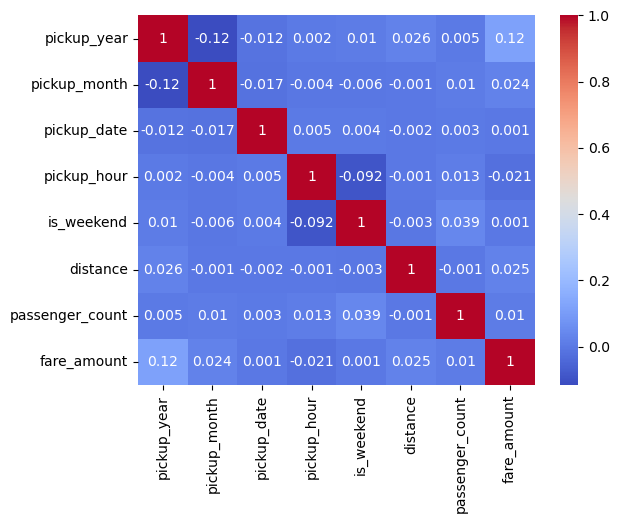

In [53]:
# to show the co-relation through 'Heatmap'

sns.heatmap(round(uber_data.corr(), 3), cmap = 'coolwarm', annot = True)
plt.show()